# Logistic Regression

Logistic regression is like linear regression, but for BINARY classification problems. It still produces a line, but the line is used to separate data between two categories of some sort, which requires a slightly different approach internally.

To illustrate logistic regression in a relevant example, let's fabricate some data that illustrates two categories of vehicles speeds: "slow" and "fast". And, we'll plot each point against two axes, one representing the distance to an upcoming bump in the road, and the other the size of the bump. In theory, cars should slow down when approaching a large bump, and slow down more the closer you get to it. This behavior could perhaps be learned from data from real drivers approaching real bumps.

We don't have a real dataset for this, but we can fabricate one. We'll use scikit-learn's "make_blobs" function to create a couple of clusters of each category ("fast" and "slow") near the corners of our graph:

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.datasets import make_blobs

n_samples = 10000 

# To generate our fabricated data set, we'll create two blobs of
# randomly distributed data at two corners of the graph...
centers = [(0.9, 0.05), (0.05, 0.94)] # centers of 2 group of data "fast" and "slow"

# call make_blobs to create 2 different clusters
X, y = make_blobs(n_samples=n_samples, n_features=2, cluster_std=0.4,
                  centers=centers, shuffle=False, random_state=42)

# Then filter out only the values that lie within [0,1]:
# filter out the results to make sure that 
# it only lie within the bound of 0 and 1
features = []
labels = []
for feature, label in zip(X, y):
    if (feature[0] >= 0 and feature[0] <= 1.0 and 
        feature[1] >= 0 and feature[1] <= 1.0):
        
        features.append(feature)
        labels.append(label)

# And convert the results back into numpy arrays:
# to feed into the machine learning model
X = np.array(features)
y = np.array(labels)

print(X)
print(y)

[[0.71221025 0.26702402]
 [0.49486755 0.17569893]
 [0.68224691 0.09436904]
 ...
 [0.86463294 0.77490236]
 [0.54314672 0.7525358 ]
 [0.73541189 0.29203208]]
[0 0 0 ... 1 1 1]


In [21]:
# testing for next code block
print(y)
y_unique = np.unique(y)
print(y_unique)

colors = cm.rainbow(np.linspace(
    0.0, # start
    1.0, # stop
    y_unique.size # since size = 2, so only generate 2 colors (num = 2) 
)) 

print('\n')
print(colors)

a = ("John", "Charles", "Mike")
b = ("Jenny", "Christy", "Monica")

x = zip(a, b)

#use the tuple() function to display a readable version of the result:

print('\n')
print(tuple(x))
print('\n')

for this_y, color in zip(y_unique, colors):
    print(this_y, color)


[0 0 0 ... 1 1 1]
[0 1]


[[5.0000000e-01 0.0000000e+00 1.0000000e+00 1.0000000e+00]
 [1.0000000e+00 1.2246468e-16 6.1232340e-17 1.0000000e+00]]


(('John', 'Jenny'), ('Charles', 'Christy'), ('Mike', 'Monica'))


0 [0.5 0.  1.  1. ]
1 [1.0000000e+00 1.2246468e-16 6.1232340e-17 1.0000000e+00]


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


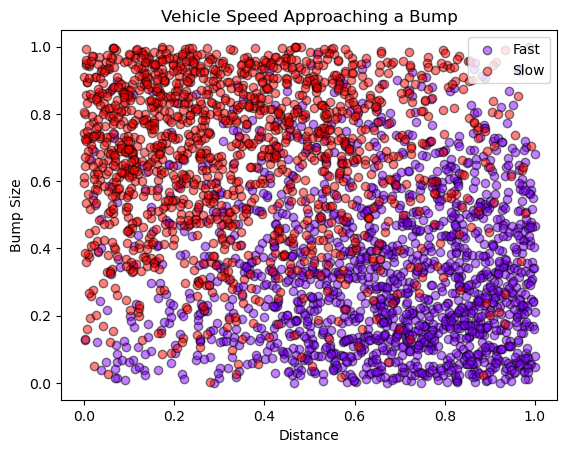

In [22]:
# Let's visualize our fabricated data set:

plt.figure()

y_unique = np.unique(y) # return only [0, 1]
class_names = ['Fast', 'Slow']
colors = cm.rainbow(np.linspace(
    0.0, # start
    1.0, # stop
    y_unique.size # since size = 2, so only generate 2 colors (num = 2) 
)) 

# create a scatter plot to visualize each one of generated points
# and color them based on their classification
for this_y, color in zip(y_unique, colors):

    # only get rows in X and y (connect rows of 2 arrays parallel) 
    # which has this_y value (label 0 at first for loop, label 1 at second for loop)
    this_X = X[y == this_y] 

    # scatter this_X array, which contains all elements having label 0 (at first for looop)
    # and elements having label 1 (at second for loop)
    plt.scatter(this_X[:, 0], this_X[:, 1], c=color,
                alpha=0.5, edgecolor='k',
                label=class_names[this_y])
                
plt.legend(loc="best")
plt.xlabel('Distance')
plt.ylabel('Bump Size')
plt.title("Vehicle Speed Approaching a Bump")
plt.show()


# look at the graph, 
# in theory a car should slow down while it's approaching a large bump
# and slow down even more when you get to that bump 
# we're trying to learn that behavior

# fundamentally we're gonna go fast if we're far away from a small bump
# and we're going very slow if we're appraching a very large bump

Creating a logistic regression model in scikit-learn is easy-peasy. There are several hyperparameters you can set on it, but most often the regularization term "C" is what people tinker with. It's default is 1.0, which we'll leave as-is for this simple problem.

After creating the classification model, we fit it to our data, which causes the model to learn the correct line for splitting the data as training data is fed into it.

In [23]:
from sklearn import linear_model

# C is a example of a hyper parameter that we're might want to tune later on to get better results
logreg = linear_model.LogisticRegression(C=1.0)

logreg.fit(X, y)

LogisticRegression()

Let's visualize our results, by using our model to plot the predicted classification values for every point on the grid's mesh. We'll also visualize the training data over it, so we can see how well the predictions match the data.

C:\Users\Acer\AppData\Local\Temp\ipykernel_144\3565075633.py:9: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  plt.scatter(X[:,0], X[:,1], c=y.astype(np.float))


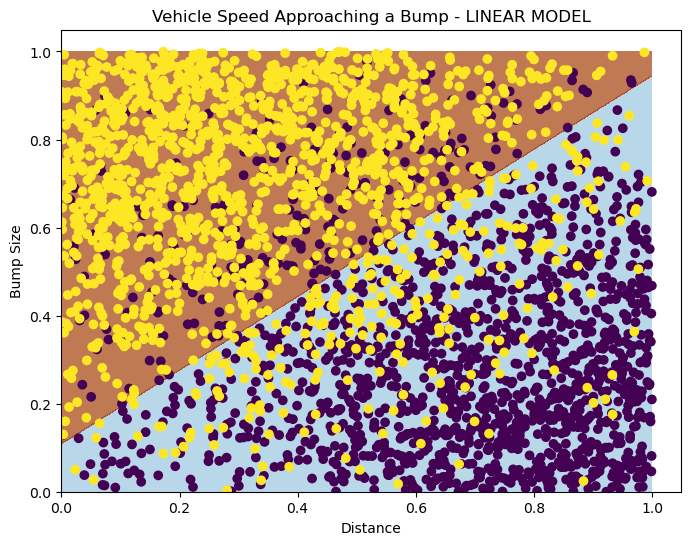

In [24]:
def plotPredictions(clf):
    xx, yy = np.meshgrid(np.arange(0, 1.0, 0.001),
                     np.arange(0, 1.0, 0.001))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    plt.figure(figsize=(8, 6))
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
    plt.scatter(X[:,0], X[:,1], c=y.astype(np.float))
    plt.xlabel('Distance')
    plt.ylabel('Bump Size')
    plt.title("Vehicle Speed Approaching a Bump - LINEAR MODEL")
    plt.show()
    
plotPredictions(logreg)

Rather than just eyeballing the results, we can use train/test to quantify how well our model predicts classifications of "slow" or "fast" speeds based on bump size and distance. Scikit-learn has a handy train_test_split function we can use to randomly divide our data set into training data and testing data. 

So, we'll train (fit) our logistic regression model using only the training data,

then call score() on it to measure its accuracy in predicting labels in the test data that it hasn't seen before.

The resulting score is just the mean accuracy of the predictions. 
So we see that on average, we predict correctly about 84% of the time. 

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg.fit(X_train, y_train)
logreg.score(X_test, y_test)

0.840983606557377

To ensure we're not overfitting to one specific train/test split, 

we can do k-fold cross validation instead. 

Scikit-learn also makes this easy; 

its cross_val_score function can run cross validation on any machine learning model for any number of folds. 

Here, we'll do 5-fold cross validation, 

and cross_val_score will automatically split up the data set for us, for each fold.

It returns the mean accuracy for each fold, 

and we can boil that down to a single metric by just taking the mean score from all the folds.

In [26]:
from sklearn.model_selection import cross_val_score

fold_scores = cross_val_score(logreg, X, y, cv=5)
print (fold_scores)
print (np.mean(fold_scores))

[0.86885246 0.84098361 0.8407225  0.82758621 0.83415435]
0.8424598239521925
